
📂 분석 시작: 파일명 ➤ **250612-S25U-wired/clean.xlsx**


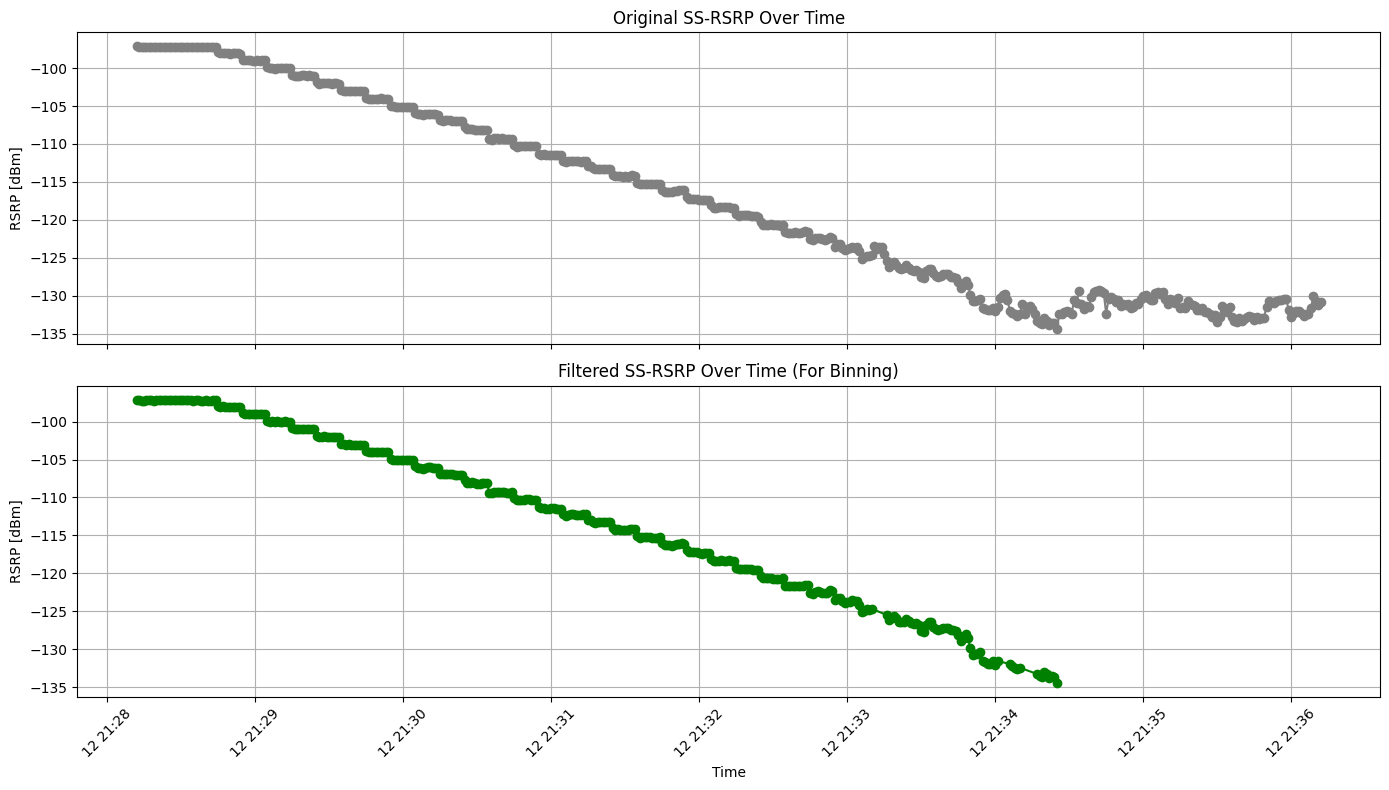


✅ Basic Info:


,Chip Type,RF Serving PCI,RF Serving PCI MOD 3,RF Serving PCI MOD 4,RF Serving PCI MOD 12,RF Serving PCI MOD 30,RF NR-ARFCN,RF BandWidth,RF Frequency [MHz],RF Subcarrier Spacing,...,Layer1 RACH Reason,Layer1 RACH Contention Type,Layer1 RACH Result,Layer1 DL Layer Num (Mode),Layer1 UL Layer Num (Mode),Layer1 UL Layer Num (Avg),Layer1 DL MIMO,Layer1 UL MIMO,Layer1 DL BWP ID,Layer1 UL BWP ID
0,5G-NR Qualcomm,1.0,1.0,1.0,1.0,1.0,158450.0,NaN,792.25,15kHz,...,NaN,NaN,NaN,1.0,1.0,1.0,2x2_MIMO,SISO,1.0,1.0



📌 RSRP 1dB Binning:


,RSRP_Bin,RF Serving PCI,RF Serving PCI MOD 3,RF Serving PCI MOD 4,RF Serving PCI MOD 12,RF Serving PCI MOD 30,RF NR-ARFCN,RF BandWidth,RF Frequency [MHz],RF Tx Beam ID 0,...,Layer1 UL RB Num (Avg),Layer1 UL RB Num (Including 0),Layer1 PDSCH Throughput [Mbps],Layer1 PUSCH Throughput [Mbps],Layer1 DL BWP ID,Layer1 UL BWP ID,Layer2 MAC DL Throughput [Mbps],Layer2 MAC UL Throughput [Mbps],RSRP_Break_Flag,Filter
0,-97 ~ -98,1.0,1.0,1.0,1.0,1.0,158450.0,20.0,792.25,3.0,...,5.602647,2.145000,110.758000,2.049206,1.0,1.0,110.755000,1.751353,0.0,1.0
1,-98 ~ -99,1.0,1.0,1.0,1.0,1.0,158450.0,20.0,792.25,3.0,...,5.762778,2.168333,110.894611,1.898056,1.0,1.0,110.888167,1.715389,0.0,1.0
2,-99 ~ -100,1.0,1.0,1.0,1.0,1.0,158450.0,20.0,792.25,3.0,...,5.844000,2.304000,111.166000,1.877400,1.0,1.0,111.166000,1.710200,0.0,1.0
3,-100 ~ -101,1.0,1.0,1.0,1.0,1.0,158450.0,20.0,792.25,3.0,...,5.806667,2.324667,110.874200,1.809267,1.0,1.0,110.859800,1.668267,0.0,1.0
4,-101 ~ -102,1.0,1.0,1.0,1.0,1.0,158450.0,20.0,792.25,3.0,...,6.115000,2.427500,110.715750,1.780750,1.0,1.0,110.608000,1.662500,0.0,1.0
5,-102 ~ -103,1.0,1.0,1.0,1.0,1.0,158450.0,20.0,792.25,3.0,...,6.383333,2.505556,110.612778,1.791556,1.0,1.0,110.394778,1.673556,0.0,1.0
6,-103 ~ -104,1.0,1.0,1.0,1.0,1.0,158450.0,20.0,792.25,3.0,...,6.619000,2.599000,110.929600,1.797400,1.0,1.0,110.849600,1.663400,0.0,1.0
7,-104 ~ -105,1.0,1.0,1.0,1.0,1.0,158450.0,20.0,792.25,3.0,...,6.818889,2.703333,110.917667,1.793333,1.0,1.0,110.286111,1.648222,0.0,1.0
8,-105 ~ -106,1.0,1.0,1.0,1.0,1.0,158450.0,20.0,792.25,3.0,...,7.015000,2.659000,110.523300,1.653000,1.0,1.0,105.496100,1.510700,0.0,1.0
9,-106 ~ -107,1.0,1.0,1.0,1.0,1.0,158450.0,20.0,792.25,3.0,...,7.268421,2.823158,105.967000,1.628632,1.0,1.0,96.160263,1.432895,0.0,1.0


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

def analyze_kpi_by_rsrp_bin(file_path, custom_bin_size=5, print_on=False):
    if print_on: print(f"\n📂 분석 시작: 파일명 ➤ **{file_path}**")

    # ============================
    # 1. 데이터 로드 및 KPI 컬럼 정리
    # ============================
    df_raw = pd.read_excel(file_path, sheet_name="Sheet1")
    df_initial_cut = df_raw.filter(regex="^(TIME_STAMP|5G KPI PCell )")
    df_initial_cut.columns = [
        col if col == "TIME_STAMP" else col.replace("5G KPI PCell ", "")
        for col in df_initial_cut.columns
    ]

    # ======================================
    # 2. (필요 시) 시험망 PCI=1만 필터링
    # ======================================
    # df_initial_cut = df_initial_cut[df_initial_cut["RF Serving PCI"] == 1].reset_index(drop=True)
    # df_initial_cut = df_initial_cut[df_initial_cut["RF Band"] != "n78"].reset_index(drop=True)
    df_main_kpi_only = df_initial_cut.copy()

    # ======================================
    # 3. RSRP 급변 감지 및 필터 생성
    # ======================================
    df_main_kpi_only = df_main_kpi_only.sort_values(by="TIME_STAMP").reset_index(drop=True)
    diff_rsrp = df_main_kpi_only["RF Serving SS-RSRP [dBm]"].diff().fillna(0)
    df_main_kpi_only["RSRP_Break_Flag"] = diff_rsrp > 1

    filter_flags = []
    current_state = True
    last_valid_rsrp = df_main_kpi_only["RF Serving SS-RSRP [dBm]"].iloc[0]

    for _, row in df_main_kpi_only.iterrows():
        rsrp = row["RF Serving SS-RSRP [dBm]"]
        is_break = row["RSRP_Break_Flag"]

        if is_break:
            current_state = False
        if not current_state and rsrp < last_valid_rsrp:
            current_state = True
        if current_state:
            last_valid_rsrp = rsrp

        filter_flags.append(current_state)

    df_main_kpi_only["Filter"] = filter_flags

    # ======================================
    # 4. 필터 적용 + NaN-only 컬럼 제거
    # ======================================
    df_filtered_rsrp = df_main_kpi_only[df_main_kpi_only["Filter"] == True].reset_index(drop=True)
    df_rsrp_for_binning = df_filtered_rsrp.sort_values(by="TIME_STAMP").dropna(axis=1, how="all").reset_index(drop=True)
    # df_rsrp_for_binning = df_rsrp_for_binning.iloc[:-2]  # 마지막 2개 행 제거

    # ======================================
    # 5. 시각화: 원본 vs 필터링된 RSRP
    # ======================================
    if print_on:
        fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
        axs[0].plot(
            df_main_kpi_only["TIME_STAMP"],
            df_main_kpi_only["RF Serving SS-RSRP [dBm]"],
            label="Original",
            color="gray",
            marker="o"
        )
        axs[0].set_title("Original SS-RSRP Over Time")
        axs[0].set_ylabel("RSRP [dBm]")
        axs[0].grid(True)
    
        axs[1].plot(
            df_rsrp_for_binning["TIME_STAMP"],
            df_rsrp_for_binning["RF Serving SS-RSRP [dBm]"],
            label="Filtered for Binning",
            color="green",
            marker="o"
        )
        axs[1].set_title("Filtered SS-RSRP Over Time (For Binning)")
        axs[1].set_xlabel("Time")
        axs[1].set_ylabel("RSRP [dBm]")
        axs[1].grid(True)
    
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    # ======================================
    # 6. 고정값 (Info) 추출
    # ======================================
    repeated_cols = [col for col in df_initial_cut.columns if df_initial_cut[col].nunique(dropna=True) == 1]
    df_static_info = df_initial_cut[repeated_cols].iloc[:1].copy()
    if print_on: 
        print("\n✅ Basic Info:")
        display(df_static_info)
    
    # ======================================
    # 7. RSRP 1dB → 5dB 구간 Binning 및 Pivot Table 생성
    # ======================================

    # ✅ 1단계: 1dB 단위 Binning
    min_rsrp = int(df_rsrp_for_binning["RF Serving SS-RSRP [dBm]"].min())
    max_rsrp = int(df_rsrp_for_binning["RF Serving SS-RSRP [dBm]"].max())

    bin_edges_1dB = list(range(min_rsrp - 1, max_rsrp + 2))
    labels_1dB = [f"{bin_edges_1dB[i+1]} ~ {bin_edges_1dB[i]}" for i in range(len(bin_edges_1dB) - 1)]

    df_rsrp_for_binning["RSRP_Bin_1dB"] = pd.cut(
        df_rsrp_for_binning["RF Serving SS-RSRP [dBm]"],
        bins=bin_edges_1dB,
        labels=labels_1dB,
        right=True,
        include_lowest=True
    )

    pivot_1dB = (
        df_rsrp_for_binning
        .groupby("RSRP_Bin_1dB", observed=True)
        .mean(numeric_only=True)
        .reset_index()
        .sort_values(by="RSRP_Bin_1dB", ascending=False)
    )
    pivot_1dB = pivot_1dB.reset_index(drop=True)

    # ✅ 마지막 N개 구간 이상치 검사
    tail_check_range = 5  # 예: 마지막 5개 bin
    spike_thresh = 10     # 예: 10Mbps 이상 튐이면 이상치
    keep_flags = [True] * len(pivot_1dB)
    for i in range(len(pivot_1dB) - tail_check_range, len(pivot_1dB)):
        if i == 0:
            continue  # 첫 구간은 비교 불가
        prev = pivot_1dB.loc[i-1, "Layer1 PDSCH Throughput [Mbps]"]
        curr = pivot_1dB.loc[i, "Layer1 PDSCH Throughput [Mbps]"]
        if curr - prev > spike_thresh:
            keep_flags[i] = False  # 이상치로 제거
    pivot_1dB = pivot_1dB[keep_flags].reset_index(drop=True)
    
    # if print_on: 
    #     print("\n📌 RSRP 1dB Binning:")
    #     display(pivot_1dB)


    # ✅ 사용자 정의 bin size로 재binning
    bin_floor = int((min_rsrp // custom_bin_size - 1) * custom_bin_size)
    bin_ceil = int((max_rsrp // custom_bin_size + 2) * custom_bin_size)
    bin_edges_custom = list(range(bin_floor, bin_ceil + 1, custom_bin_size))
    labels_custom = [f"{bin_edges_custom[i+1]} ~ {bin_edges_custom[i]}" for i in range(len(bin_edges_custom) - 1)]
    pivot_1dB["RSRP_Bin"] = pd.cut(
        pivot_1dB["RF Serving SS-RSRP [dBm]"],
        bins=bin_edges_custom,
        labels=labels_custom,
        right=True,
        include_lowest=True
    )
    numeric_cols = pivot_1dB.select_dtypes(include="number").columns
    pivot_custom = (
        pivot_1dB
        .groupby("RSRP_Bin", observed=True)[numeric_cols]
        .mean()
        .reset_index()
        .sort_values(by="RSRP_Bin", ascending=False)
    )
    pivot_custom = pivot_custom.reset_index(drop=True)

    if print_on:
        print(f"\n📌 RSRP {custom_bin_size}dB Binning:")
        display(pivot_custom)

    return pivot_custom

pivot =analyze_kpi_by_rsrp_bin("250612-S25U-wired/clean.xlsx", custom_bin_size=1, print_on=True)

In [4]:
### TEST ####
def search_kpi_with_keyword(df):
    kpi_keywords = ["rsrp", "mcs", "rb", "ri2", "bler", "pdsch throughput",'cqi','sinr']
    kpi_candidate_columns = [
        col for col in df.columns
        if any(keyword in col.lower() for keyword in kpi_keywords)
        and "ul" not in col.lower()
        and 'flag' not in col.lower()
        and 'mac' not in col.lower()
        and 'pusch' not in col.lower()
    ]
    final_kpi_columns = [
        col for col in kpi_candidate_columns
        if "(mode)" not in col.lower()
        and "(including 0)" not in col.lower()
    ]    
    display(df[final_kpi_columns].reset_index(drop=True))

search_kpi_with_keyword(pivot)

,RSRP_Bin,RF Serving SS-RSRP [dBm],RF Serving SS-SINR [dB],RF Best Beam SS-RSRP [dBm],RF RI2 Rate [%],RF CQI,Layer1 DL BLER [%],Layer1 DL R-BLER [%],Layer1 DL MCS (Avg),Layer1 DL RB Num (Avg),Layer1 PDSCH Throughput [Mbps]
0,-97 ~ -98,-97.215882,27.027353,-97.215882,0.0,15.000000,0.002941,0.00,26.168824,104.079118,110.758000
1,-98 ~ -99,-98.502222,25.883333,-98.502222,0.0,15.000000,0.005556,0.00,26.175556,104.097222,110.894611
2,-99 ~ -100,-99.752000,24.664000,-99.752000,0.0,15.000000,0.000000,0.00,26.174000,104.102000,111.166000
3,-100 ~ -101,-100.585333,23.912000,-100.585333,0.0,15.000000,0.013333,0.00,26.172667,104.092667,110.874200
4,-101 ~ -102,-101.702500,22.902500,-101.702500,0.0,15.000000,0.100000,0.00,26.160000,104.042500,110.715750
5,-102 ~ -103,-102.228889,22.347778,-102.228889,0.0,14.986667,0.232222,0.00,26.104444,104.022222,110.612778
6,-103 ~ -104,-103.222000,21.441000,-103.222000,0.0,15.000000,0.070000,0.00,26.173000,104.102000,110.929600
7,-104 ~ -105,-104.151111,19.625556,-104.151111,0.0,15.000000,0.565556,0.00,26.172222,104.096667,110.917667
8,-105 ~ -106,-105.160000,15.315000,-105.160000,0.0,14.908000,4.541000,0.00,26.075000,104.092000,110.523300
9,-106 ~ -107,-106.531579,14.185789,-106.531579,0.0,12.367368,8.950526,0.00,24.958421,103.952632,105.967000


In [5]:
def filter_and_rename_kpi(df):
    
    # ✅ 기본 KPI 매핑 정의
    rename_dict = {
        "RSRP_Bin": "NR_RSRP[dBm]",
        "RF RI2 Rate [%]": "RI2_Rate[%]",
        "Layer1 DL BLER [%]": "DL_BLER[%]",
        "Layer1 DL MCS (Avg)": "DL_MCS",
        "Layer1 DL RB Num (Avg)": "DL_RB_Num",
        "Layer1 PDSCH Throughput [Mbps]": "DL_Tput[Mbps]",
        "RF CQI": "CQI",
        "RF Serving SS-SINR [dB]": "SINR[dB]",
    }

    # ✅ 실제 존재하는 컬럼 중 rename_dict 기준으로 필터링
    columns_to_display = [col for col in rename_dict if col in df.columns]

    # ✅ 출력용 테이블 생성 및 컬럼명 변경
    df_renamed = df[columns_to_display].rename(columns=rename_dict)
    df_renamed = df_renamed.reset_index(drop=True)

    # ✅ 칼럼 순서 지정 (존재하지 않는 항목은 자동 제거)
    final_columns = ['NR_RSRP[dBm]', 'DL_Tput[Mbps]', 'DL_MCS', 'DL_BLER[%]', 'SINR[dB]', "CQI", 'RI2_Rate[%]', 'DL_RB_Num']
    final_columns = [col for col in final_columns if col in df_renamed.columns]
    df_renamed = df_renamed[final_columns]

    return df_renamed
    
filter_and_rename_kpi(pivot)

,NR_RSRP[dBm],DL_Tput[Mbps],DL_MCS,DL_BLER[%],SINR[dB],CQI,RI2_Rate[%],DL_RB_Num
0,-97 ~ -98,110.758000,26.168824,0.002941,27.027353,15.000000,0.0,104.079118
1,-98 ~ -99,110.894611,26.175556,0.005556,25.883333,15.000000,0.0,104.097222
2,-99 ~ -100,111.166000,26.174000,0.000000,24.664000,15.000000,0.0,104.102000
3,-100 ~ -101,110.874200,26.172667,0.013333,23.912000,15.000000,0.0,104.092667
4,-101 ~ -102,110.715750,26.160000,0.100000,22.902500,15.000000,0.0,104.042500
5,-102 ~ -103,110.612778,26.104444,0.232222,22.347778,14.986667,0.0,104.022222
6,-103 ~ -104,110.929600,26.173000,0.070000,21.441000,15.000000,0.0,104.102000
7,-104 ~ -105,110.917667,26.172222,0.565556,19.625556,15.000000,0.0,104.096667
8,-105 ~ -106,110.523300,26.075000,4.541000,15.315000,14.908000,0.0,104.092000
9,-106 ~ -107,105.967000,24.958421,8.950526,14.185789,12.367368,0.0,103.952632


In [9]:
import os
import pandas as pd

def concat_kpi(test_dir, bin_size=5):

    directory_path = os.getcwd()
    input_path = os.path.join(directory_path, test_dir)
    # print(input_path)
    
    excel_files = [
        f for f in os.listdir(input_path)
        if f.endswith(".xlsx") and 
        '$' not in f and
        "rsrp_bin" not in f
    ]

    clean = [f.replace('.xlsx', '') for f in excel_files if "clean" in f]
    others = [f.replace('.xlsx', '') for f in excel_files if "clean" not in f]
    others_sorted = sorted(others, key=lambda x: int(x.replace('dBm', '')), reverse=False)
    sources = clean + others_sorted
    source_order = {src: idx for idx, src in enumerate(sources)}

    # print(source_order)
    
    # ✅ 처리 결과 누적 저장
    dfs = []
    for filename in excel_files:
        file_path = os.path.join(input_path, filename)
        file_tag = os.path.splitext(filename)[0]
        try:
            pivot = analyze_kpi_by_rsrp_bin(file_path, custom_bin_size= bin_size, print_on=False)
            df = filter_and_rename_kpi(pivot)
            df["IF_Power"] = file_tag
            dfs.append(df)
            
        except Exception as e:
            print(f"❌ 처리 실패: {filename} → {e}")
    
    df_stacked = pd.concat(dfs, ignore_index=True)
    df_stacked = df_stacked.reset_index(drop=True)
    
    # 1. RSRP_Bin: 정수 기준 첫 값 추출 (예: "-65 ~ -60" → -65)
    df_stacked["RSRP_Bin_SortKey"] = df_stacked["NR_RSRP[dBm]"].str.extract(r"(-?\d+)").astype(int)
    
    # 2. Source 우선순위 명시 (NoPower → -50dBm → ...)
    # print(source_order)
    df_stacked["Source_SortKey"] = df_stacked["IF_Power"].map(source_order).fillna(99)
    
    # 3. 정렬 수행
    df_stacked = df_stacked.sort_values(
        by=["RSRP_Bin_SortKey", "Source_SortKey"],
        ascending=[False, True]
    )
    
    # 4. 정렬 키 제거 후 MultiIndex 재설정
    df_stacked = df_stacked.drop(columns=["RSRP_Bin_SortKey", "Source_SortKey"])
    df_stacked = df_stacked.set_index(["NR_RSRP[dBm]", "IF_Power"])

    output_path = os.path.join(test_dir, f"{test_dir}_kpi_tables_rsrp_bin_{bin_size}dB.xlsx")
    df_stacked.to_excel(output_path, index=True, float_format="%.2f")
    
    return df_stacked, source_order

df_stacked, source_order = concat_kpi(test_dir = "250612-S25U-wired", bin_size=1)
display(df_stacked)

DL_Tput[Mbps]     DL_MCS  DL_BLER[%]   SINR[dB]    CQI  \
NR_RSRP[dBm] IF_Power                                                           
-96 ~ -97    -48dBm       110.969842  26.176316    0.000000  27.916842  15.00   
             -40dBm        94.231400  23.177000    0.003333  27.775333  15.00   
             -32dBm       110.871682  26.174091    0.000000  27.060000  15.00   
-97 ~ -98    clean        110.758000  26.168824    0.002941  27.027353  15.00   
             -48dBm       110.876917  26.175833    0.008333  26.836667  15.00   
...                              ...        ...         ...        ...    ...   
-134 ~ -135  clean          1.190000   3.630000    3.470000  -5.970000   3.00   
             -40dBm         2.674750   5.015000    7.177500  -6.540000   3.75   
-136 ~ -137  -40dBm         1.392000   1.740000    2.350000  -7.840000   4.00   
-145 ~ -146  -40dBm         0.189000   0.000000    0.000000 -22.730000   4.00   
-149 ~ -150  -40dBm         0.066000   1.670000   33.330000 -27.380000   4.00   

                       RI2_Rate[%]   DL_RB_Num  
NR_RSRP[dBm] IF_Power                           
-96 ~ -97    -48dBm            0.0  104.100000  
             -40dBm            0.0   91.292000  
             -32dBm            0.0  104.100000  
-97 ~ -98    clean             0.0  104.079118  
             -48dBm            0.0  104.098333  
...                            ...         ...  
-134 ~ -135  clean             0.0   74.950000  
             -40dBm            0.0   91.817500  
-136 ~ -137  -40dBm            0.0   99.510000  
-145 ~ -146  -40dBm            0.0   94.200000  
-149 ~ -150  -40dBm            0.0   48.000000  

[151 rows x 7 columns]

In [10]:
import matplotlib.pyplot as plt
import math
from matplotlib.ticker import MaxNLocator, MultipleLocator, FixedLocator


def plot_kpis_by_rsrp(test_dir, bin_size=1, if_name="ATSC3.0 / 6MHz", rsrp_class='all'):

    df_stacked, source_order = concat_kpi(test_dir=test_dir, bin_size=bin_size)

    plot_config = {
        "DL_Tput[Mbps]": {"ylabel": "PDSCH Throughput (Mbps)", "title": "PHY Throughput"},
        "RI2_Rate[%]": {"ylabel": "RI2 Rate (%)", "title": "RI2 Rate"},
        "DL_MCS": {"ylabel": "DL MCS Index", "title": "MCS"},
        "CQI": {"ylabel": "CQI", "title": "CQI"},
        "SINR[dB]": {"ylabel": "SINR (dB)", "title": "SINR"},
        "DL_BLER[%]": {"ylabel": "DL BLER (%)", "title": "BLER"},
    }

    colors = ['blue','green','red','orange','gray','brown','purple']
    markers = ['D', 's', '^', 'o', '*', 'x', 'P', 'v']
    linestyles = ['-', '--', '-.', ':']

    df_stacked_reset = df_stacked.reset_index()
    rsrp_range = df_stacked_reset["NR_RSRP[dBm]"].str.replace(" ", "").str.split("~")
    df_stacked_reset["RSRP_Int"] = rsrp_range.apply(lambda x: (int(x[0]) + int(x[1])) // 2)

    max_val = df_stacked_reset["RSRP_Int"].max()
    rounded_up = int(math.ceil((max_val + 1) / 5.0)) * 5
    rsrp_start = rounded_up
    
    rsrp_end, offset = -135, 2
    if rsrp_class == 'high':
        rsrp_end, offset = -95, 1
    elif rsrp_class == 'low':
        rsrp_start, rsrp_end, offset = -115, -135, 1
    
    xtick_labels = list(range(rsrp_start, rsrp_end-1, -5))
    df_filter = df_stacked_reset[(df_stacked_reset["RSRP_Int"] < rsrp_start) & (df_stacked_reset["RSRP_Int"] > rsrp_end)]
    
    n_rows, n_cols = 2, 3
    subplot_width, subplot_height = 7, 6  # 각 서브플롯 크기 (인치 단위)
    figsize = (n_cols * subplot_width, n_rows * subplot_height+1)
    
    fig, axs = plt.subplots(n_rows, n_cols, figsize=figsize)
    plt.subplots_adjust(hspace=0.8,wspace=0.8)
    axs = axs.flatten()

    for i, (kpi, cfg) in enumerate(plot_config.items()):
        ax = axs[i]
        for j, source in enumerate(source_order):
            subset = df_filter[df_filter["IF_Power"] == source]
            subset = subset.sort_values(by="RSRP_Int", ascending=False)

            ax.plot(
                subset["RSRP_Int"],
                subset[kpi],
                marker=markers[j % len(markers)],
                color=colors[j % len(colors)],
                label=source,
                # linestyle=linestyles[j % len(linestyles)],
                linewidth=1,
                markersize=3
            )

        ax.set_title(cfg["title"], fontsize=15, weight="bold", pad=5)
        ax.set_xlabel("NR RSRP [dBm]", fontsize=13)
        ax.set_ylabel(cfg["ylabel"], fontsize=13, labelpad=5)
        ax.tick_params(axis='x', labelrotation=45, labelsize=10)
        ax.tick_params(axis='y', labelsize=10)

        ax.set_xticks(xtick_labels)
        ax.set_xticklabels(xtick_labels)
        ax.set_xlim(rsrp_start+offset, rsrp_end-offset)
        ax.legend(title=f"Interference Power\n({if_name})", fontsize=11, title_fontsize=11)

        
        if kpi == "DL_Tput[Mbps]":
            if rsrp_class == 'low':
                y_val = 15 # 700M 커버리지 기준 값
                ax.axhline(y=y_val, color='black', linestyle='--', linewidth=1.5)
                ax.text(
                    x=ax.get_xlim()[1] + 1,   # x축 오른쪽 끝
                    y=y_val + 0.5,            # y값 약간 위
                    s=f"{y_val} Mbps",        # 표시할 텍스트
                    fontsize=11,
                    color='black',
                    verticalalignment='bottom',
                    horizontalalignment='right'
                )

        if rsrp_class in ['high', 'low']:
            ax.xaxis.set_minor_locator(MultipleLocator(1))  # 1dB 단위 grid
            ax.xaxis.set_major_locator(FixedLocator(xtick_labels))  # 5dB 간격 tick 고정   
            ax.grid(True, which='major', axis='both', linestyle='--', linewidth=0.7, alpha=0.9)
            ax.grid(True, which='minor', axis='x', linestyle=':', linewidth=0.5, alpha=0.6)
        else:
            ax.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5, alpha=0.6)

    if rsrp_class == 'all':
        fig.suptitle(f"DL KPI Trends [RSRP Full Range] - {test_dir}", fontsize=18, weight='bold', y=1.002)
    elif rsrp_class == 'high':
        fig.suptitle(f"DL KPI Trends [RSRP ≥ {rsrp_end} dBm] - {test_dir}", fontsize=18, weight='bold', y=1.002)
    elif rsrp_class == 'low':
        fig.suptitle(f"DL KPI Trends [RSRP ≤ {rsrp_start} dBm] - {test_dir}", fontsize=18, weight='bold', y=1.002)

    plt.tight_layout()

    output_path = os.path.join(test_dir, f"{test_dir}_rsrp_bin_{bin_size}dB_{rsrp_class}.png")
    plt.savefig(output_path, dpi=300, bbox_inches='tight', pad_inches=0.3)

    plt.show()

In [11]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FixedLocator, LogFormatter
import os

def plot_tput_logscale_low_rsrp(test_dir, bin_size=1, if_name="ATSC3.0 / 6MHz", rsrp_threshold=-115):
    colors = ['blue','green','red','orange','gray','brown','purple']
    markers = ['D', 's', '^', 'o', '*', 'x', 'P', 'v']

    fig, ax = plt.subplots(figsize=(7, 6))
    df_stacked, source_order = concat_kpi(test_dir=test_dir, bin_size=bin_size)
    df_stacked_reset = df_stacked.reset_index()
    rsrp_range = df_stacked_reset["NR_RSRP[dBm]"].str.replace(" ", "").str.split("~")
    df_stacked_reset["RSRP_Int"] = rsrp_range.apply(lambda x: (int(x[0]) + int(x[1])) // 2)

    # ✅ 입력받은 RSRP threshold 기준으로 구간 설정
    rsrp_start, rsrp_end, offset = rsrp_threshold, -135, 1
    xtick_labels = list(range(rsrp_start, rsrp_end - 1, -5))
    df_filter = df_stacked_reset[
        (df_stacked_reset["RSRP_Int"] < rsrp_start) &
        (df_stacked_reset["RSRP_Int"] > rsrp_end)
    ]

    for j, source in enumerate(source_order):
        subset = df_filter[df_filter["IF_Power"] == source]
        subset = subset.sort_values(by="RSRP_Int", ascending=False)

        ax.plot(
            subset["RSRP_Int"],
            subset["DL_Tput[Mbps]"],
            marker=markers[j % len(markers)],
            color=colors[j % len(colors)],
            label=source,
            linewidth=1,
            markersize=3
        )

    ax.set_title(f"RSRP ≤ {rsrp_threshold} dBm", fontsize=14, weight='bold')
    ax.set_xlabel("NR RSRP [dBm]", fontsize=12)
    ax.set_ylabel("PDSCH Throughput (Mbps, log)", fontsize=12)
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(LogFormatter(labelOnlyBase=False))
    ax.tick_params(axis='x', labelrotation=45, labelsize=10)
    ax.tick_params(axis='y', labelsize=10)

    ax.set_xticks(xtick_labels)
    ax.set_xticklabels(xtick_labels)
    ax.set_xlim(rsrp_start + 2, rsrp_end - 2)

    # 기준선 15 Mbps
    y_val = 15
    ax.axhline(y=y_val, color='black', linestyle='--', linewidth=1.5)
    ax.text(
        x=ax.get_xlim()[1] + 1,
        y=y_val * 1.05,
        s=f"{y_val} Mbps",
        fontsize=10,
        color='black',
        va='bottom',
        ha='right'
    )

    # grid
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.xaxis.set_major_locator(FixedLocator(xtick_labels))
    ax.grid(True, which='major', axis='x', linestyle='--', linewidth=0.7, alpha=0.9)
    ax.grid(True, which='minor', axis='x', linestyle=':', linewidth=0.5, alpha=0.6)
    ax.grid(True, which='major', axis='y', linestyle='--', linewidth=0.7, alpha=0.9)

    ax.legend(title=f"Interference\n({if_name})", fontsize=9, title_fontsize=9)


    fig.suptitle(f"DL Throughput (Log Scale) - {test_dir}", fontsize=16, weight='bold', y=0.93)

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    output_path = os.path.join(test_dir, f"{test_dir}_rsrp_low_tput_logscale.png")
    plt.savefig(output_path, dpi=300, bbox_inches='tight', pad_inches=0.3)

    plt.show()

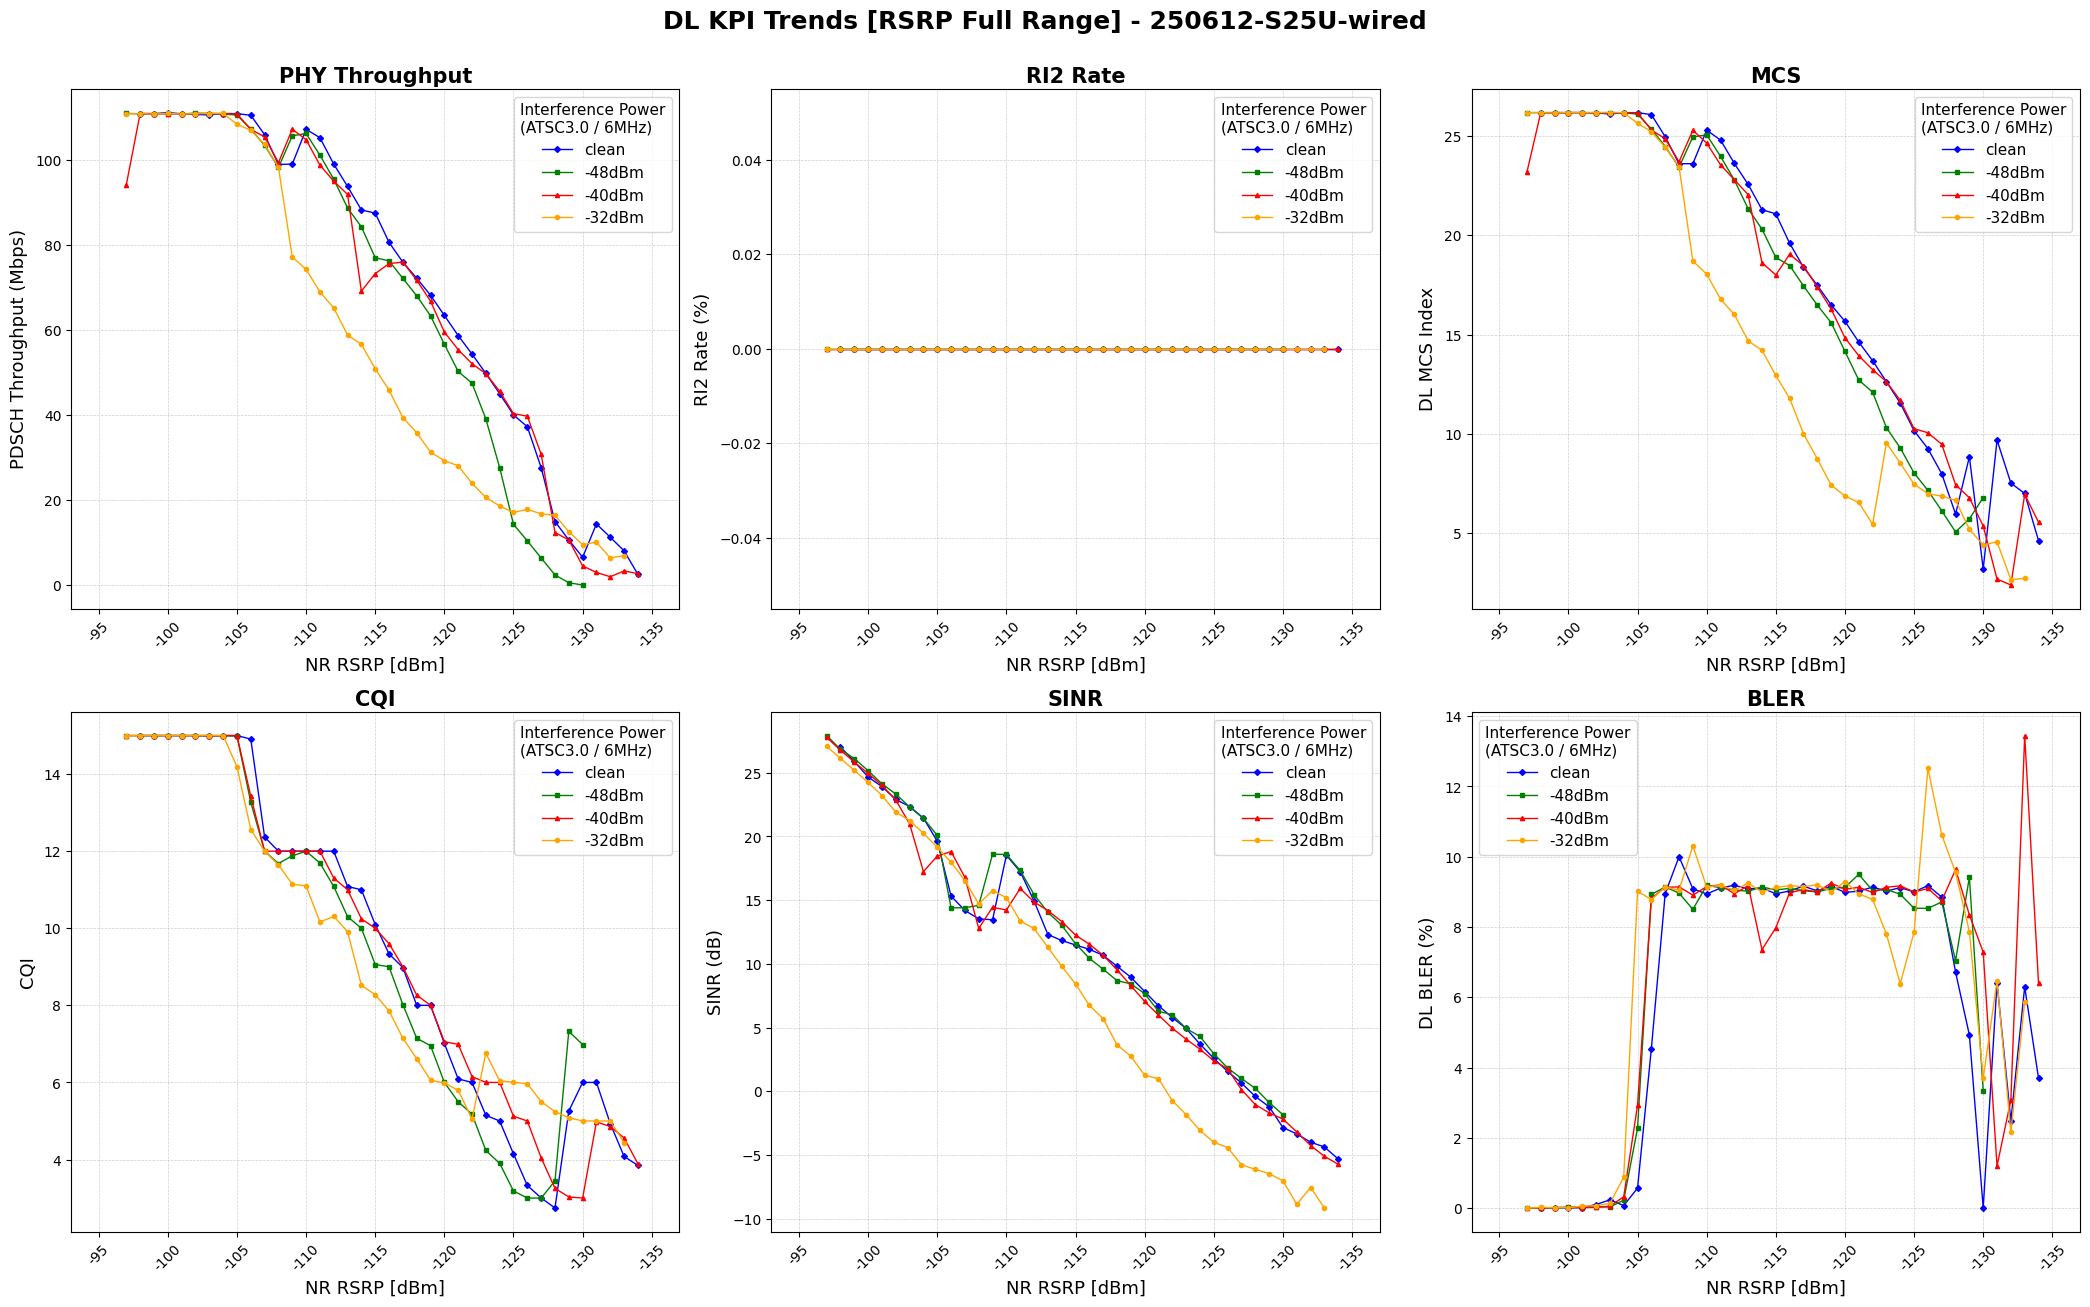

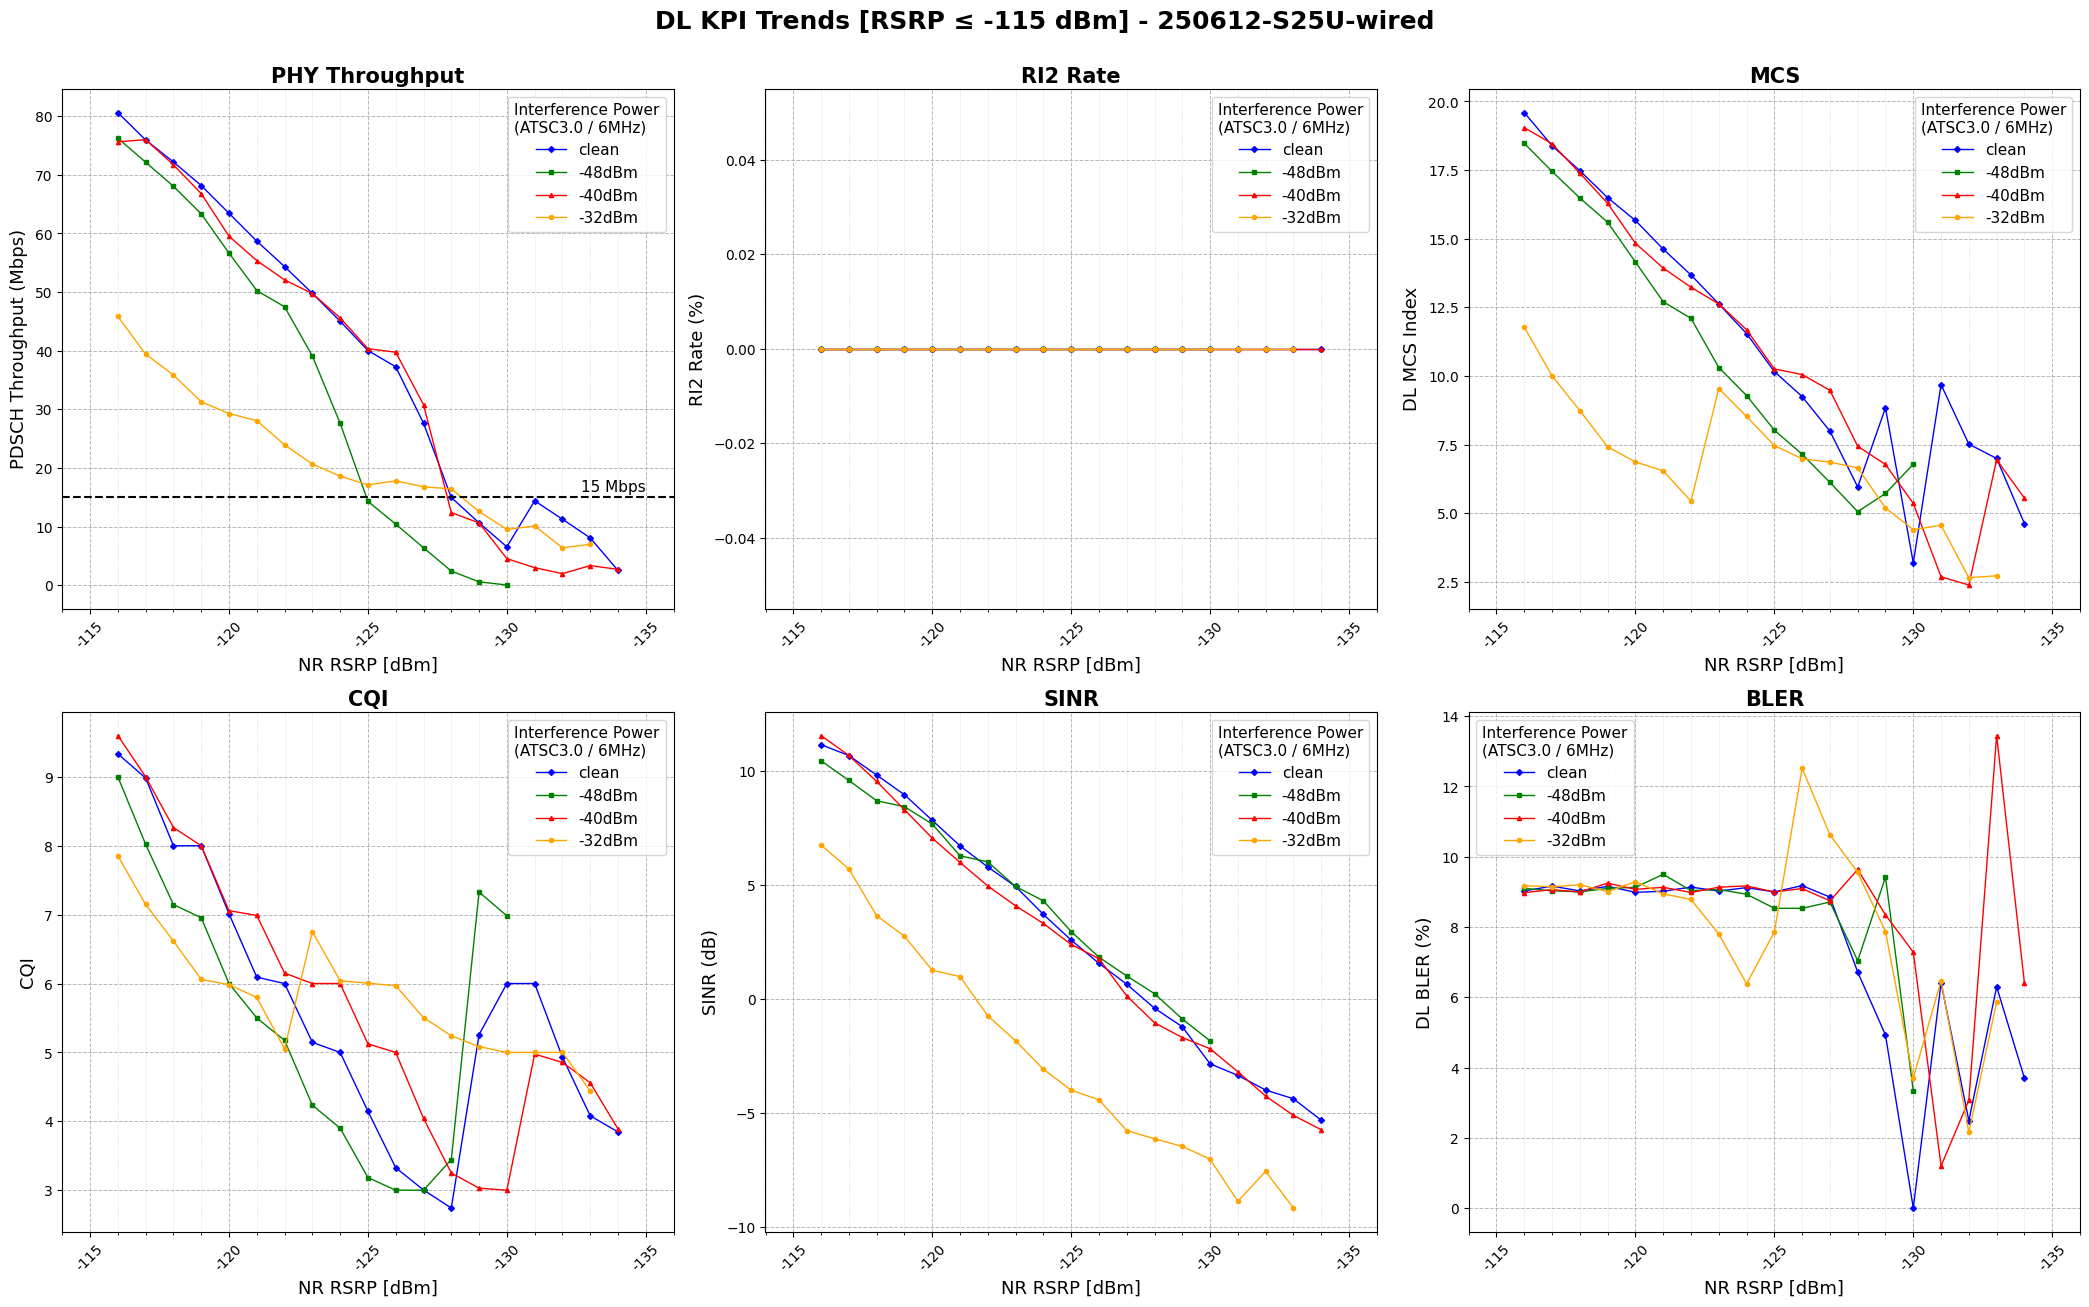

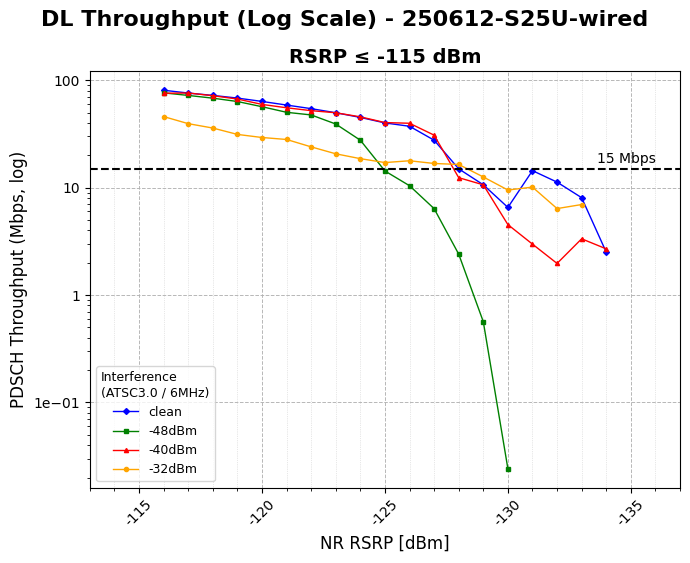

In [12]:
ue_list = ['250612-S25U-wired']
for ue in ue_list:
    plot_kpis_by_rsrp(test_dir=ue, bin_size=1, if_name="ATSC3.0 / 6MHz", rsrp_class='all')
    print()
    # plot_kpis_by_rsrp(test_dir=ue, bin_size=1, if_name="ATSC3.0 / 6MHz", rsrp_class='high')
    # print()
    plot_kpis_by_rsrp(test_dir=ue, bin_size=1, if_name="ATSC3.0 / 6MHz", rsrp_class='low')
    print()
    plot_tput_logscale_low_rsrp(test_dir=ue, bin_size=1, rsrp_threshold=-115)